# Aggregated Representations

## Data Preparation

In [1]:
import joblib

aggregated_records = joblib.load('/kaggle/input/mandarin-context-aware-representations/aggregated_records.joblib')

## Combinations Evaluation

In [2]:
import numpy as np
import pandas as pd
from itertools import combinations
from tqdm import tqdm

# Helper functions
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def jaccard_similarity(set_a, set_b):
    if not set_a or not set_b:
        return 0.0
    inter = len(set_a & set_b)
    union = len(set_a | set_b)
    return inter / union if union > 0 else 0.0

def pinyin_group(comp_i, comp_j):
    """comp = [init_idx, final_idx, tone_idx]"""
    init_i, final_i, tone_i = comp_i
    init_j, final_j, tone_j = comp_j
    if init_i == init_j and final_i == final_j and tone_i == tone_j:
        return 'same_syllable'
    elif init_i == init_j and final_i == final_j:
        return 'same_initial_final'
    elif init_i == init_j:
        return 'same_initial'
    elif final_i == final_j:
        return 'same_final'
    elif tone_i == tone_j:
        return 'same_tone'
    else:
        return 'none'


# Pre-normalize for cosine similarity
def normalize_rows(mat):
    norms = np.linalg.norm(mat, axis=1, keepdims=True)
    norms[norms == 0] = 1
    return mat / norms

In [3]:
!rm -rf /kaggle/working/sampled_pair_similarities.csv

In [4]:
import csv
import random
import numpy as np
from tqdm import tqdm

def pinyin_flags(comp_i, comp_j):
    """Return (same_syllable, same_initial, same_final, same_tone) as 0/1 ints."""
    init_i, final_i, tone_i = comp_i
    init_j, final_j, tone_j = comp_j
    same_syllable = (init_i == init_j and final_i == final_j and tone_i == tone_j)
    same_initial = (init_i == init_j)
    same_final = (final_i == final_j)
    same_tone = (tone_i == tone_j)
    return int(same_syllable), int(same_initial), int(same_final), int(same_tone)

# Pre‑extract features into lists aligned with keys
keys = list(aggregated_records.keys())
n = len(keys)

# Pre‑compute normalized vectors for numeric similarities
hidden_norm = np.array([aggregated_records[k]['hidden'] for k in keys])
semantic_norm = np.array([aggregated_records[k]['semantic'] for k in keys])
acoustic_norm = np.array([aggregated_records[k]['acoustic'] for k in keys])

hidden_norm = normalize_rows(hidden_norm)
semantic_norm = normalize_rows(semantic_norm)
acoustic_norm = normalize_rows(acoustic_norm)

# Pre‑extract other features
wubi_sets = [aggregated_records[k]['wubi_set'] for k in keys]
pinyin_comps = [aggregated_records[k]['pinyin_components'] for k in keys]

# Parameters
sample_size = 1_000_000   # number of random pairs to generate
random.seed(42)

# Generate unique random pairs (i < j)
sampled_pairs = set()
while len(sampled_pairs) < sample_size:
    i = random.randrange(n)
    j = random.randrange(n)
    if i != j:
        sampled_pairs.add((min(i, j), max(i, j)))

print(f"Generated {len(sampled_pairs)} unique pairs.")

# Open CSV file for writing
with open('sampled_pair_similarities.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['char_pinyin_i', 'char_pinyin_j', 'hidden_sim', 'semantic_sim',
                     'acoustic_sim', 'wubi_jaccard', 'same_syllable', 'same_initial',
                     'same_final', 'same_tone'])

    for (i, j) in tqdm(sampled_pairs, desc="Processing sampled pairs"):
        # Cosine similarities
        h_sim = np.dot(hidden_norm[i], hidden_norm[j])
        s_sim = np.dot(semantic_norm[i], semantic_norm[j])
        a_sim = np.dot(acoustic_norm[i], acoustic_norm[j])
        # Jaccard
        set_i, set_j = wubi_sets[i], wubi_sets[j]
        if set_i and set_j:
            inter = len(set_i & set_j)
            union = len(set_i | set_j)
            w_jac = inter / union if union > 0 else 0.0
        else:
            w_jac = 0.0
        # Pinyin flags
        comp_i, comp_j = pinyin_comps[i], pinyin_comps[j]
        same_syl, same_init, same_fin, same_tone = pinyin_flags(comp_i, comp_j)
        writer.writerow([keys[i], keys[j], h_sim, s_sim, a_sim, w_jac,
                         same_syl, same_init, same_fin, same_tone])

print("Sampling and CSV writing complete.")

Generated 1000000 unique pairs.


Processing sampled pairs: 100%|██████████| 1000000/1000000 [00:21<00:00, 46257.47it/s]

Sampling and CSV writing complete.


In [5]:
similarity_df = pd.read_csv("/kaggle/working/sampled_pair_similarities.csv")

In [6]:
similarity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   char_pinyin_i  1000000 non-null  object 
 1   char_pinyin_j  1000000 non-null  object 
 2   hidden_sim     1000000 non-null  float64
 3   semantic_sim   1000000 non-null  float64
 4   acoustic_sim   1000000 non-null  float64
 5   wubi_jaccard   1000000 non-null  float64
 6   same_syllable  1000000 non-null  int64  
 7   same_initial   1000000 non-null  int64  
 8   same_final     1000000 non-null  int64  
 9   same_tone      1000000 non-null  int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 76.3+ MB


In [7]:
similarity_df.describe()

,hidden_sim,semantic_sim,acoustic_sim,wubi_jaccard,same_syllable,same_initial,same_final,same_tone
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,0.065071,0.660898,0.009186,0.204392,0.005499,0.072928,0.050246,0.271298
std,0.068478,0.116820,0.226539,0.111764,0.073951,0.260018,0.218452,0.444630
min,-0.167934,0.141527,-0.558461,0.034483,0.000000,0.000000,0.000000,0.000000
25%,0.020478,0.578712,-0.148883,0.125000,0.000000,0.000000,0.000000,0.000000
50%,0.050716,0.664411,-0.018453,0.166667,0.000000,0.000000,0.000000,0.000000
75%,0.093501,0.750438,0.130771,0.250000,0.000000,0.000000,0.000000,1.000000
max,0.985498,0.991200,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Define the formula
formula = 'hidden_sim ~ semantic_sim + acoustic_sim + wubi_jaccard + same_syllable + same_initial + same_final + same_tone'

# Fit OLS model
model = smf.ols(formula, data=similarity_df).fit()

# Print summary with robust standard errors
print(model.summary())
print("\n" + "="*80 + "\n")
print("Coefficients with robust standard errors (HC3):")
print(model.get_robustcov_results(cov_type='HC3').summary())

                            OLS Regression Results                            
Dep. Variable:             hidden_sim   R-squared:                       0.075
Model:                            OLS   Adj. R-squared:                  0.075
Method:                 Least Squares   F-statistic:                 1.152e+04
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        08:45:56   Log-Likelihood:             1.3011e+06
No. Observations:             1000000   AIC:                        -2.602e+06
Df Residuals:                  999992   BIC:                        -2.602e+06
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.0319      0.000     79.626

## PCA

In [9]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Collect all hidden vectors
X = np.vstack([rec['hidden'] for rec in aggregated_records.values()])
print(f"Shape of hidden matrix: {X.shape}")

Shape of hidden matrix: (11507, 1024)


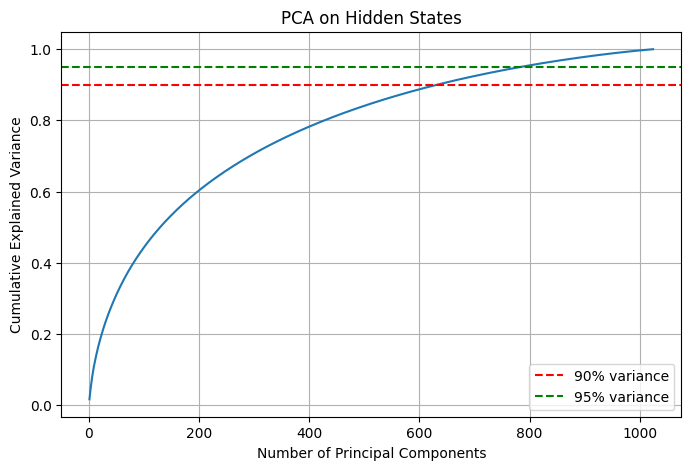

In [10]:
# Standardize (center, scale to unit variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Cumulative explained variance
explained_var = pca.explained_variance_ratio_
cumulative = np.cumsum(explained_var)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative)+1), cumulative)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% variance')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA on Hidden States')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# Find number of components needed for 90% variance
k = 100

# Fit PCA again with n_components = k
pca_k = PCA(n_components=k)
X_reduced = pca_k.fit_transform(X_scaled)
print(f"Reduced shape: {X_reduced.shape}")
print(f"Explained variance: {cumulative[k]}")

Reduced shape: (11507, 100)
Explained variance: 0.44528087973594666


In [12]:
for i, record in enumerate(aggregated_records.values()):
    hidden_reduced = X_reduced[i, :]
    record['hidden'] = hidden_reduced

In [13]:
aggregated_records[('他', 'ta1')]['hidden'].shape

(100,)

In [14]:
!rm -rf /kaggle/working/pca_sampled_pair_similarities.csv

In [15]:
import csv
import random
import numpy as np
from tqdm import tqdm

def pinyin_flags(comp_i, comp_j):
    """Return (same_syllable, same_initial, same_final, same_tone) as 0/1 ints."""
    init_i, final_i, tone_i = comp_i
    init_j, final_j, tone_j = comp_j
    same_syllable = (init_i == init_j and final_i == final_j and tone_i == tone_j)
    same_initial = (init_i == init_j)
    same_final = (final_i == final_j)
    same_tone = (tone_i == tone_j)
    return int(same_syllable), int(same_initial), int(same_final), int(same_tone)

# Pre‑extract features into lists aligned with keys
keys = list(aggregated_records.keys())
n = len(keys)

# Pre‑compute normalized vectors for numeric similarities
hidden_norm = np.array([aggregated_records[k]['hidden'] for k in keys])
semantic_norm = np.array([aggregated_records[k]['semantic'] for k in keys])
acoustic_norm = np.array([aggregated_records[k]['acoustic'] for k in keys])

hidden_norm = normalize_rows(hidden_norm)
semantic_norm = normalize_rows(semantic_norm)
acoustic_norm = normalize_rows(acoustic_norm)

# Pre‑extract other features
wubi_sets = [aggregated_records[k]['wubi_set'] for k in keys]
pinyin_comps = [aggregated_records[k]['pinyin_components'] for k in keys]

# Parameters
sample_size = 1_000_000   # number of random pairs to generate
random.seed(42)

# Generate unique random pairs (i < j)
sampled_pairs = set()
while len(sampled_pairs) < sample_size:
    i = random.randrange(n)
    j = random.randrange(n)
    if i != j:
        sampled_pairs.add((min(i, j), max(i, j)))

print(f"Generated {len(sampled_pairs)} unique pairs.")

# Open CSV file for writing
with open('pca_sampled_pair_similarities.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['char_pinyin_i', 'char_pinyin_j', 'hidden_sim', 'semantic_sim',
                     'acoustic_sim', 'wubi_jaccard', 'same_syllable', 'same_initial',
                     'same_final', 'same_tone'])

    for (i, j) in tqdm(sampled_pairs, desc="Processing sampled pairs"):
        # Cosine similarities
        h_sim = np.dot(hidden_norm[i], hidden_norm[j])
        s_sim = np.dot(semantic_norm[i], semantic_norm[j])
        a_sim = np.dot(acoustic_norm[i], acoustic_norm[j])
        # Jaccard
        set_i, set_j = wubi_sets[i], wubi_sets[j]
        if set_i and set_j:
            inter = len(set_i & set_j)
            union = len(set_i | set_j)
            w_jac = inter / union if union > 0 else 0.0
        else:
            w_jac = 0.0
        # Pinyin flags
        comp_i, comp_j = pinyin_comps[i], pinyin_comps[j]
        same_syl, same_init, same_fin, same_tone = pinyin_flags(comp_i, comp_j)
        writer.writerow([keys[i], keys[j], h_sim, s_sim, a_sim, w_jac,
                         same_syl, same_init, same_fin, same_tone])

print("Sampling and CSV writing complete.")

Generated 1000000 unique pairs.


Processing sampled pairs: 100%|██████████| 1000000/1000000 [00:21<00:00, 47568.55it/s]

Sampling and CSV writing complete.


In [16]:
similarity_df = pd.read_csv("/kaggle/working/pca_sampled_pair_similarities.csv")

In [17]:
similarity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   char_pinyin_i  1000000 non-null  object 
 1   char_pinyin_j  1000000 non-null  object 
 2   hidden_sim     1000000 non-null  float64
 3   semantic_sim   1000000 non-null  float64
 4   acoustic_sim   1000000 non-null  float64
 5   wubi_jaccard   1000000 non-null  float64
 6   same_syllable  1000000 non-null  int64  
 7   same_initial   1000000 non-null  int64  
 8   same_final     1000000 non-null  int64  
 9   same_tone      1000000 non-null  int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 76.3+ MB


In [18]:
similarity_df.describe()

,hidden_sim,semantic_sim,acoustic_sim,wubi_jaccard,same_syllable,same_initial,same_final,same_tone
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,0.006319,0.660898,0.009186,0.204392,0.005499,0.072928,0.050246,0.271298
std,0.132663,0.116820,0.226539,0.111764,0.073951,0.260018,0.218452,0.444630
min,-0.408570,0.141527,-0.558461,0.034483,0.000000,0.000000,0.000000,0.000000
25%,-0.080744,0.578712,-0.148883,0.125000,0.000000,0.000000,0.000000,0.000000
50%,-0.022204,0.664411,-0.018453,0.166667,0.000000,0.000000,0.000000,0.000000
75%,0.062555,0.750438,0.130771,0.250000,0.000000,0.000000,0.000000,1.000000
max,0.997181,0.991200,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [19]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Define the formula
formula = 'hidden_sim ~ semantic_sim + acoustic_sim + wubi_jaccard + same_syllable + same_initial + same_final + same_tone'

# Fit OLS model
model = smf.ols(formula, data=similarity_df).fit()

# Print summary with robust standard errors
print(model.summary())
print("\n" + "="*80 + "\n")
print("Coefficients with robust standard errors (HC3):")
print(model.get_robustcov_results(cov_type='HC3').summary())

                            OLS Regression Results                            
Dep. Variable:             hidden_sim   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                 1.827e+04
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        08:46:27   Log-Likelihood:             6.6119e+05
No. Observations:             1000000   AIC:                        -1.322e+06
Df Residuals:                  999992   BIC:                        -1.322e+06
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -0.0546      0.001    -72.024

# Context Dependent Representations

## Data Preparation

In [20]:
import joblib

contextual_records = joblib.load('/kaggle/input/mandarin-context-aware-representations/character_records.joblib')

In [21]:
len(contextual_records)

290350

In [22]:
contextual_records[0].keys()

dict_keys(['char', 'pinyin', 'hidden', 'acoustic', 'semantic', 'wubi_set', 'pinyin_components'])

## Combinations Evaluation

In [23]:
!rm -rf /kaggle/working/contextual_pair_similarities.csv

In [24]:
import random
import csv
import numpy as np
from tqdm import tqdm

# Helper functions
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def jaccard_similarity(set_a, set_b):
    if not set_a or not set_b:
        return 0.0
    inter = len(set_a & set_b)
    union = len(set_a | set_b)
    return inter / union if union > 0 else 0.0

def pinyin_flags(comp_i, comp_j):
    init_i, final_i, tone_i = comp_i
    init_j, final_j, tone_j = comp_j
    same_syllable = (init_i == init_j and final_i == final_j and tone_i == tone_j)
    same_initial = (init_i == init_j)
    same_final = (final_i == final_j)
    same_tone = (tone_i == tone_j)
    return int(same_syllable), int(same_initial), int(same_final), int(same_tone)

# contextual_records: list of dicts with keys:
# ['char', 'pinyin', 'hidden', 'acoustic', 'semantic', 'wubi_set', 'pinyin_components']
N = len(contextual_records)
sample_size = 1_000_000          # number of random pairs to generate
random.seed(42)

# Sample unique pairs (i, j) with i < j
sampled_pairs = set()
while len(sampled_pairs) < sample_size:
    i = random.randrange(N)
    j = random.randrange(N)
    if i != j:
        sampled_pairs.add((min(i, j), max(i, j)))

print(f"Sampled {len(sampled_pairs)} unique occurrence pairs.")

# Write to CSV
with open('contextual_pair_similarities.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['char_i', 'char_j', 'pinyin_i', 'pinyin_j', 'hidden_sim', 'semantic_sim',
                     'acoustic_sim', 'wubi_jaccard', 'same_syllable', 'same_initial',
                     'same_final', 'same_tone'])
    for i, j in tqdm(sampled_pairs, desc="Processing pairs"):
        rec_i = contextual_records[i]
        rec_j = contextual_records[j]
        # Cosine similarities
        h_sim = cosine_similarity(rec_i['hidden'], rec_j['hidden'])
        s_sim = cosine_similarity(rec_i['semantic'], rec_j['semantic'])
        a_sim = cosine_similarity(rec_i['acoustic'], rec_j['acoustic'])
        # Jaccard similarity on Wubi token sets
        w_jac = jaccard_similarity(rec_i['wubi_set'], rec_j['wubi_set'])
        # Pinyin group flags
        same_syl, same_init, same_fin, same_tone = pinyin_flags(
            rec_i['pinyin_components'], rec_j['pinyin_components']
        )
        writer.writerow([rec_i['char'], rec_j['char'], rec_i['pinyin'], rec_j['pinyin'],
                         h_sim, s_sim, a_sim, w_jac, same_syl, same_init, same_fin, same_tone])

Sampled 1000000 unique occurrence pairs.


Processing pairs: 100%|██████████| 1000000/1000000 [00:35<00:00, 27949.92it/s]


In [25]:
similarity_df = pd.read_csv("/kaggle/working/contextual_pair_similarities.csv")

In [26]:
similarity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   char_i         1000000 non-null  object 
 1   char_j         1000000 non-null  object 
 2   pinyin_i       1000000 non-null  object 
 3   pinyin_j       1000000 non-null  object 
 4   hidden_sim     1000000 non-null  float64
 5   semantic_sim   1000000 non-null  float64
 6   acoustic_sim   1000000 non-null  float64
 7   wubi_jaccard   1000000 non-null  float64
 8   same_syllable  1000000 non-null  int64  
 9   same_initial   1000000 non-null  int64  
 10  same_final     1000000 non-null  int64  
 11  same_tone      1000000 non-null  int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 91.6+ MB


In [27]:
similarity_df.describe()

,hidden_sim,semantic_sim,acoustic_sim,wubi_jaccard,same_syllable,same_initial,same_final,same_tone
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,0.034727,0.547348,0.013641,0.237245,0.006083,0.066129,0.061842,0.240872
std,0.079405,0.068965,0.210072,0.126878,0.077756,0.248508,0.240868,0.427613
min,-0.239207,0.098488,-0.575575,0.034483,0.000000,0.000000,0.000000,0.000000
25%,-0.002598,0.505546,-0.130902,0.166667,0.000000,0.000000,0.000000,0.000000
50%,0.019223,0.553505,-0.012207,0.200000,0.000000,0.000000,0.000000,0.000000
75%,0.052467,0.595684,0.124279,0.250000,0.000000,0.000000,0.000000,0.000000
max,0.990637,0.898264,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [28]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Define the formula
formula = 'hidden_sim ~ semantic_sim + acoustic_sim + wubi_jaccard + same_syllable + same_initial + same_final + same_tone'

# Fit OLS model
model = smf.ols(formula, data=similarity_df).fit()

# Print summary with robust standard errors
print(model.summary())
print("\n" + "="*80 + "\n")
print("Coefficients with robust standard errors (HC3):")
print(model.get_robustcov_results(cov_type='HC3').summary())

                            OLS Regression Results                            
Dep. Variable:             hidden_sim   R-squared:                       0.486
Model:                            OLS   Adj. R-squared:                  0.486
Method:                 Least Squares   F-statistic:                 1.350e+05
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        08:48:02   Log-Likelihood:             1.4468e+06
No. Observations:             1000000   AIC:                        -2.894e+06
Df Residuals:                  999992   BIC:                        -2.894e+06
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -0.0109      0.000    -23.315

## PCA

In [29]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Collect all hidden vectors
X = np.vstack([rec['hidden'] for rec in contextual_records])
print(f"Shape of hidden matrix: {X.shape}")

Shape of hidden matrix: (290350, 1024)


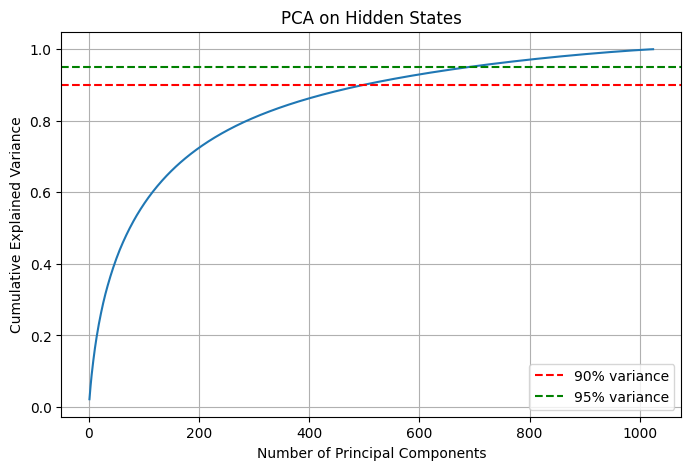

In [30]:
# Standardize (center, scale to unit variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Cumulative explained variance
explained_var = pca.explained_variance_ratio_
cumulative = np.cumsum(explained_var)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative)+1), cumulative)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% variance')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA on Hidden States')
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# Find number of components needed for 90% variance
k = 100

# Fit PCA again with n_components = k
pca_k = PCA(n_components=k)
X_reduced = pca_k.fit_transform(X_scaled)
print(f"Reduced shape: {X_reduced.shape}")
print(f"Explained variance: {cumulative[k]}")

Reduced shape: (290350, 100)
Explained variance: 0.5699437260627747


In [32]:
for i, record in enumerate(contextual_records):
    hidden_reduced = X_reduced[i, :]
    record['hidden'] = hidden_reduced

In [33]:
contextual_records[0]['hidden'].shape

(100,)

In [34]:
!rm -rf /kaggle/working/pca_contextual_pair_similarities.csv

In [35]:
import random
import csv
import numpy as np
from tqdm import tqdm

# Helper functions
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def jaccard_similarity(set_a, set_b):
    if not set_a or not set_b:
        return 0.0
    inter = len(set_a & set_b)
    union = len(set_a | set_b)
    return inter / union if union > 0 else 0.0

def pinyin_flags(comp_i, comp_j):
    init_i, final_i, tone_i = comp_i
    init_j, final_j, tone_j = comp_j
    same_syllable = (init_i == init_j and final_i == final_j and tone_i == tone_j)
    same_initial = (init_i == init_j)
    same_final = (final_i == final_j)
    same_tone = (tone_i == tone_j)
    return int(same_syllable), int(same_initial), int(same_final), int(same_tone)

# contextual_records: list of dicts with keys:
# ['char', 'pinyin', 'hidden', 'acoustic', 'semantic', 'wubi_set', 'pinyin_components']
N = len(contextual_records)
sample_size = 1_000_000          # number of random pairs to generate
random.seed(42)

# Sample unique pairs (i, j) with i < j
sampled_pairs = set()
while len(sampled_pairs) < sample_size:
    i = random.randrange(N)
    j = random.randrange(N)
    if i != j:
        sampled_pairs.add((min(i, j), max(i, j)))

print(f"Sampled {len(sampled_pairs)} unique occurrence pairs.")

# Write to CSV
with open('pca_contextual_pair_similarities.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['char_i', 'char_j', 'pinyin_i', 'pinyin_j', 'hidden_sim', 'semantic_sim',
                     'acoustic_sim', 'wubi_jaccard', 'same_syllable', 'same_initial',
                     'same_final', 'same_tone'])
    for i, j in tqdm(sampled_pairs, desc="Processing pairs"):
        rec_i = contextual_records[i]
        rec_j = contextual_records[j]
        # Cosine similarities
        h_sim = cosine_similarity(rec_i['hidden'], rec_j['hidden'])
        s_sim = cosine_similarity(rec_i['semantic'], rec_j['semantic'])
        a_sim = cosine_similarity(rec_i['acoustic'], rec_j['acoustic'])
        # Jaccard similarity on Wubi token sets
        w_jac = jaccard_similarity(rec_i['wubi_set'], rec_j['wubi_set'])
        # Pinyin group flags
        same_syl, same_init, same_fin, same_tone = pinyin_flags(
            rec_i['pinyin_components'], rec_j['pinyin_components']
        )
        writer.writerow([rec_i['char'], rec_j['char'], rec_i['pinyin'], rec_j['pinyin'],
                         h_sim, s_sim, a_sim, w_jac, same_syl, same_init, same_fin, same_tone])

Sampled 1000000 unique occurrence pairs.


Processing pairs: 100%|██████████| 1000000/1000000 [00:36<00:00, 27266.64it/s]


In [36]:
similarity_df = pd.read_csv("/kaggle/working/pca_contextual_pair_similarities.csv")

In [37]:
similarity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   char_i         1000000 non-null  object 
 1   char_j         1000000 non-null  object 
 2   pinyin_i       1000000 non-null  object 
 3   pinyin_j       1000000 non-null  object 
 4   hidden_sim     1000000 non-null  float64
 5   semantic_sim   1000000 non-null  float64
 6   acoustic_sim   1000000 non-null  float64
 7   wubi_jaccard   1000000 non-null  float64
 8   same_syllable  1000000 non-null  int64  
 9   same_initial   1000000 non-null  int64  
 10  same_final     1000000 non-null  int64  
 11  same_tone      1000000 non-null  int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 91.6+ MB


In [38]:
similarity_df.describe()

,hidden_sim,semantic_sim,acoustic_sim,wubi_jaccard,same_syllable,same_initial,same_final,same_tone
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,0.000873,0.547348,0.013641,0.237245,0.006083,0.066129,0.061842,0.240872
std,0.124740,0.068965,0.210072,0.126878,0.077756,0.248508,0.240868,0.427613
min,-0.381312,0.098488,-0.575575,0.034483,0.000000,0.000000,0.000000,0.000000
25%,-0.066503,0.505546,-0.130902,0.166667,0.000000,0.000000,0.000000,0.000000
50%,-0.025743,0.553505,-0.012207,0.200000,0.000000,0.000000,0.000000,0.000000
75%,0.032044,0.595684,0.124279,0.250000,0.000000,0.000000,0.000000,0.000000
max,0.998831,0.898264,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [39]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Define the formula
formula = 'hidden_sim ~ semantic_sim + acoustic_sim + wubi_jaccard + same_syllable + same_initial + same_final + same_tone'

# Fit OLS model
model = smf.ols(formula, data=similarity_df).fit()

# Print summary with robust standard errors
print(model.summary())
print("\n" + "="*80 + "\n")
print("Coefficients with robust standard errors (HC3):")
print(model.get_robustcov_results(cov_type='HC3').summary())

                            OLS Regression Results                            
Dep. Variable:             hidden_sim   R-squared:                       0.407
Model:                            OLS   Adj. R-squared:                  0.407
Method:                 Least Squares   F-statistic:                 9.803e+04
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        08:49:40   Log-Likelihood:             9.2382e+05
No. Observations:             1000000   AIC:                        -1.848e+06
Df Residuals:                  999992   BIC:                        -1.848e+06
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -0.0789      0.001    -99.788

## Multicollinearity Test

In [40]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Assume similarities_df contains the predictors (excluding hidden_sim)
X = similarity_df[['semantic_sim', 'acoustic_sim', 'wubi_jaccard', 
                     'same_syllable', 'same_initial', 'same_final', 'same_tone']]

# Add constant term for VIF calculation (VIF is defined for intercept-included design)
X_with_const = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]
print(vif_data)

        Variable        VIF
0          const  67.754218
1   semantic_sim   1.006223
2   acoustic_sim   1.636754
3   wubi_jaccard   1.131281
4  same_syllable   1.385156
5   same_initial   1.143655
6     same_final   1.285308
7      same_tone   1.228232


## Linearity and Heteroscedasticity

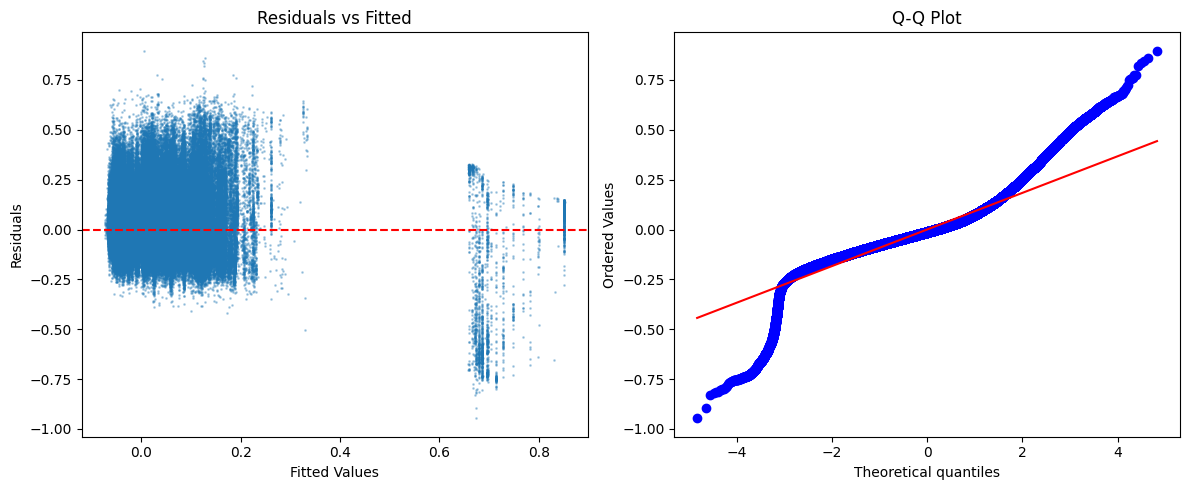

In [41]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Fit OLS model again to get residuals
model = sm.OLS(similarity_df['hidden_sim'], X_with_const).fit()
residuals = model.resid
fitted = model.fittedvalues

# Residuals vs fitted plot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(fitted, residuals, alpha=0.3, s=1)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')

# Q-Q plot for normality
plt.subplot(1,2,2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot')
plt.tight_layout()
plt.show()

## Cross-Validation

In [42]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression

X = similarity_df[['semantic_sim', 'acoustic_sim', 'wubi_jaccard', 
                     'same_syllable', 'same_initial', 'same_final', 'same_tone']]
y = similarity_df['hidden_sim']

cv = KFold(n_splits=5, shuffle=True, random_state=42)
lr = LinearRegression()
scores = cross_val_score(lr, X, y, cv=cv, scoring='r2')

print(f"Cross-validated R²: mean = {scores.mean():.4f} ± {scores.std():.4f}")
print(f"Individual fold R²: {scores}")

Cross-validated R²: mean = 0.4069 ± 0.0041
Individual fold R²: [0.40899886 0.40871887 0.39941848 0.40589854 0.41148934]


## Non-linear Modeling

In [43]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost model
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
r2_xgb = r2_score(y_test, y_pred)
print(f"XGBoost R² on test set: {r2_xgb:.4f}")

# Feature importance
importance = pd.DataFrame({'feature': X.columns, 'importance': xgb_model.feature_importances_})
print(importance.sort_values('importance', ascending=False))

XGBoost R² on test set: 0.4548
         feature  importance
3  same_syllable    0.866938
6      same_tone    0.040544
5     same_final    0.037283
4   same_initial    0.028427
2   wubi_jaccard    0.023677
1   acoustic_sim    0.002571
0   semantic_sim    0.000560
